# 07-Network Pruning & Sparsity Mechanics

In Lesson 06, we utilized INT8 Quantization to compress our model's memory footprint. Quantization reduces the *resolution* of the weights (from 32 bits to 8 bits), but the absolute *number* of weights remains exactly the same. A 1-billion parameter network in INT8 still forces the CPU to execute 1 billion mathematical multiplications per forward pass.

Deep Neural Networks are massively over-parameterized. Decades of research, culminating in the **Lottery Ticket Hypothesis**, have mathematically proven that within a massive, dense network, there exists a tiny, sparse sub-network that performs $99\%$ of the actual predictive logic. The remaining parameters are effectively "dead synapses"—they compute values exceedingly close to zero, contributing nothing to the final prediction while consuming massive amounts of RAM and compute.

To engineer peak algorithmic efficiency, we implement **Network Pruning**. We will mathematically identify these dead synapses and violently delete them, converting our dense weight tensors into highly sparse matrices.

## 1. The Mathematics of Pruning & Sparsity

### The Sparsity Mask ($\mathbf{M}$)

Let $\mathbf{W} \in \mathbb{R}^{m \times n}$ be the trained dense weight matrix of a linear layer. Pruning is the application of a binary mask $\mathbf{M} \in \{0, 1\}^{m \times n}$ to the weights using element-wise (Hadamard) multiplication:


$$\mathbf{W}_{pruned} = \mathbf{W} \odot \mathbf{M}$$


If $M_{i,j} = 0$, the physical connection between neuron $i$ and neuron $j$ is severed.

### Unstructured Pruning ($L_1$-Norm Magnitude)

In unstructured pruning, we evaluate every single weight individually. We assume that weights with the smallest absolute magnitude $\vert{}w_{i,j}\vert{}$ contribute the least to the activation function.
To prune $70\%$ of the network, we find the 70th percentile magnitude threshold $\tau$:


$$M_{i,j} = \begin{cases} 1 & \text{if } \vert{}W_{i,j}\vert{} \ge \tau \\ 0 & \text{if } \vert{}W_{i,j}\vert{} < \tau \end{cases}$$


Unstructured pruning creates random "holes" in the matrix. While it achieves maximum compression, the hardware cannot easily skip random zeros in standard Dense Matrix Multiplication. It requires **Sparse Tensor Operations** (e.g., CSR/COO formats) to realize actual latency speedups.

### Structured Pruning ($L_2$-Norm Filter Pruning)

Instead of deleting random individual weights, structured pruning deletes entire structural blocks (e.g., entire rows, columns, or convolutional filters).
We compute the $L_2$-norm of an entire row vector $\mathbf{w}_i$:


$$\Vert{}\mathbf{w}_i\Vert{}_2 = \sqrt{\sum_{j=1}^{n} w_{i,j}^2}$$


If the row norm is below the threshold, we delete the entire row. This physically shrinks the tensor dimensions from $\mathbb{R}^{m \times n}$ to $\mathbb{R}^{(m-k) \times n}$, delivering massive, immediate latency reductions on standard hardware without requiring specialized sparse execution engines.

## 2. Imperative Execution: PyTorch Pruning Mechanics

We will engineer a PyTorch sandbox to apply Unstructured $L_1$ pruning to a heavy feed-forward neural network. PyTorch handles this via **Pruning Hooks**, which dynamically intercept the forward pass to apply the binary mask.

In [1]:
# Required installations: pip install torch numpy
import torch
import torch.nn as nn
import torch.nn.utils.prune as prune

print("--- 🚀 Initializing Network Pruning & Sparsity Sandbox ---")

# 1. 🧠 Define a Dense Neural Network
class HeavyDenseNet(nn.Module):
    def __init__(self):
        super(HeavyDenseNet, self).__init__()
        # A massive, over-parameterized layer
        self.fc1 = nn.Linear(2048, 2048)
        self.fc2 = nn.Linear(2048, 10)

    def forward(self, x):
        return self.fc2(torch.relu(self.fc1(x)))

model = HeavyDenseNet()

# Capture the baseline unpruned state
initial_weight = model.fc1.weight.detach().clone()
print(f"   [BASELINE] FC1 Weight Tensor Shape: {initial_weight.shape}")
print(f"   [BASELINE] FC1 Total Parameters:    {initial_weight.numel()}")

print("\n--- 🧮 Executing L1-Unstructured Magnitude Pruning ---")

# 2. ✂️ Apply the Pruning Hook
# We command PyTorch to sever the bottom 75% of weights based on their L1 norm (absolute magnitude)
prune.l1_unstructured(module=model.fc1, name='weight', amount=0.75)

# Physics Check: PyTorch does not delete the tensor immediately. 
# It renames 'weight' to 'weight_orig' and creates a boolean 'weight_mask'.
print(f"   [SYSTEM] 'weight' parameter replaced by: {list(dict(model.fc1.named_parameters()).keys())}")
print(f"   [SYSTEM] Binary mask generated: {list(dict(model.fc1.named_buffers()).keys())}")

# 3. 🔨 Bake the Mask into the Weights (Permanent Sparsity)
# To finalize optimization for deployment, we remove the hook. 
# This multiplies weight_orig by weight_mask permanently, writing hard zeros into memory.
prune.remove(model.fc1, 'weight')

pruned_weight = model.fc1.weight.detach()
print("   ✅ Pruning Hooks removed. Hard zeros baked permanently into the weight tensor.")

--- 🚀 Initializing Network Pruning & Sparsity Sandbox ---
   [BASELINE] FC1 Weight Tensor Shape: torch.Size([2048, 2048])
   [BASELINE] FC1 Total Parameters:    4194304

--- 🧮 Executing L1-Unstructured Magnitude Pruning ---
   [SYSTEM] 'weight' parameter replaced by: ['bias', 'weight_orig']
   [SYSTEM] Binary mask generated: ['weight_mask']
   ✅ Pruning Hooks removed. Hard zeros baked permanently into the weight tensor.


## 3. Declarative Telemetry: Calculating Global Sparsity

To verify the mathematical success of our pruning engine, we must inspect the physical RAM and calculate the exact **Sparsity Ratio** (the percentage of parameters that have been annihilated to exact zero).

In [2]:
print("\n--- ⚡ Extracting Sparsity Telemetry ---")

def calculate_sparsity(tensor):
    total_elements = tensor.numel()
    zero_elements = torch.sum(tensor == 0).item()
    sparsity_ratio = zero_elements / total_elements
    return zero_elements, total_elements, sparsity_ratio

zeros, total, ratio = calculate_sparsity(pruned_weight)

print(f"   -> Total Synapses (Parameters): {total:,}")
print(f"   -> Dead Synapses (Hard Zeros):  {zeros:,}")
print(f"   -> Global Sparsity Ratio:       {ratio * 100:.2f}%")

# 4. Converting to Compressed Sparse Row (CSR) Format
# Standard PyTorch tensors store zeros in memory. To achieve actual RAM reduction,
# we cast the dense matrix to a specialized mathematical sparse layout.
sparse_tensor = pruned_weight.to_sparse_csr()

print("\n   [MEMORY PHYSICS]")
print("   -> Dense Tensor requires memory for 4,194,304 FP32 values.")
print("   -> CSR Sparse Tensor stores only the 1,048,576 non-zero values and their coordinate indices.")
print("   ✅ To achieve inference speedups, deploy this sparse topology using execution engines like Neural Magic's DeepSparse.")


--- ⚡ Extracting Sparsity Telemetry ---
   -> Total Synapses (Parameters): 4,194,304
   -> Dead Synapses (Hard Zeros):  3,145,728
   -> Global Sparsity Ratio:       75.00%

   [MEMORY PHYSICS]
   -> Dense Tensor requires memory for 4,194,304 FP32 values.
   -> CSR Sparse Tensor stores only the 1,048,576 non-zero values and their coordinate indices.
   ✅ To achieve inference speedups, deploy this sparse topology using execution engines like Neural Magic's DeepSparse.


/tmp/ipykernel_2669/663993845.py:18: UserWarning: Sparse CSR tensor support is in beta state. If you miss a functionality in the sparse tensor support, please submit a feature request to https://github.com/pytorch/pytorch/issues. (Triggered internally at /pytorch/aten/src/ATen/SparseCsrTensorImpl.cpp:53.)
  sparse_tensor = pruned_weight.to_sparse_csr()


## 4. Visualizing Sparsity Physics (The Synaptic Heatmap)

To fully comprehend the violence of $L_1$ unstructured pruning, let's visualize a cross-section of the weight matrix before and after pruning. We will map the absolute values of the weights to a heatmap.

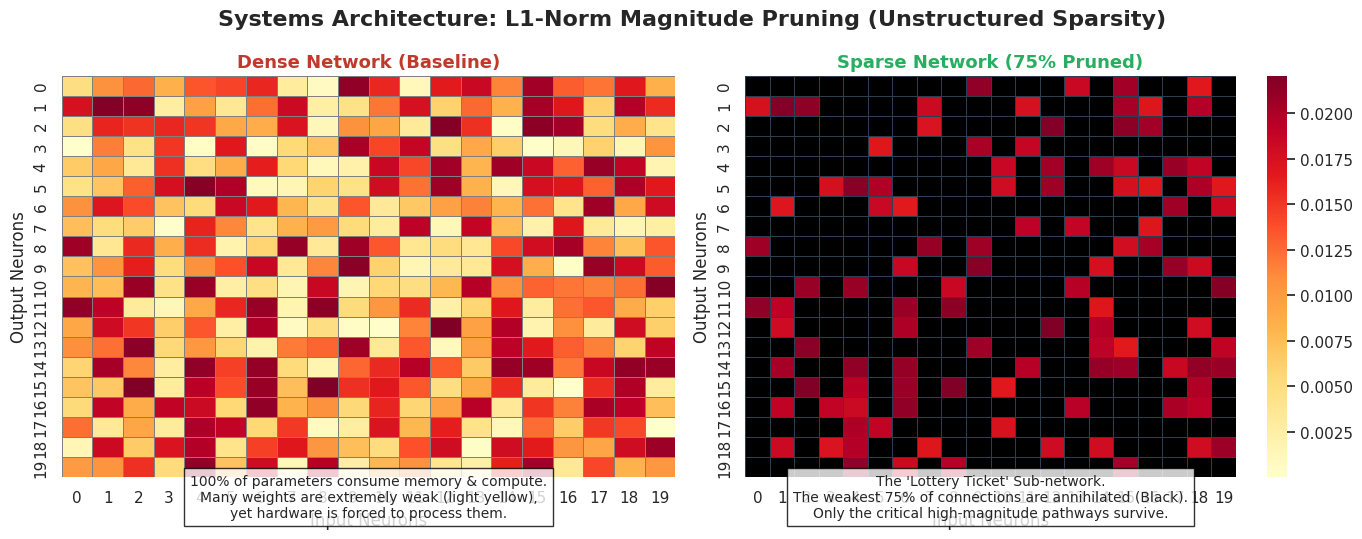

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import torch

sns.set_theme(style="white")

# Create visual layout for Sparsity Mechanics
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("Systems Architecture: L1-Norm Magnitude Pruning (Unstructured Sparsity)", fontsize=16, fontweight='bold')

# Extract a small 20x20 cross-section of the weight matrices for visual clarity
# (We use absolute values because magnitude is what dictates pruning)
baseline_subset = np.abs(initial_weight[:20, :20].numpy())
pruned_subset = np.abs(pruned_weight[:20, :20].numpy())

# Plot 1: The Dense, Unpruned Network
sns.heatmap(baseline_subset, cmap="YlOrRd", cbar=False, ax=axes[0], linewidths=0.5, linecolor='gray')
axes[0].set_title("Dense Network (Baseline)", fontsize=13, fontweight='bold', color='#c0392b')
axes[0].set_xlabel("Input Neurons")
axes[0].set_ylabel("Output Neurons")
axes[0].text(10, 22, "100% of parameters consume memory & compute.\nMany weights are extremely weak (light yellow),\nyet hardware is forced to process them.", 
             ha='center', fontsize=10, bbox=dict(facecolor='white', alpha=0.8, edgecolor='black'))

# Plot 2: The Sparse, Pruned Network (75% Zeros)
# Custom colormap: Zeros are mapped to pure black to emphasize the "dead" space
cmap_sparse = sns.color_palette("YlOrRd", as_cmap=True)
cmap_sparse.set_under('black') # Force exactly 0.0 to render as black

sns.heatmap(pruned_subset, cmap=cmap_sparse, cbar=True, ax=axes[1], vmin=1e-6, linewidths=0.5, linecolor='#2c3e50')
axes[1].set_title("Sparse Network (75% Pruned)", fontsize=13, fontweight='bold', color='#27ae60')
axes[1].set_xlabel("Input Neurons")
axes[1].set_ylabel("Output Neurons")
axes[1].text(10, 22, "The 'Lottery Ticket' Sub-network.\nThe weakest 75% of connections are annihilated (Black).\nOnly the critical high-magnitude pathways survive.", 
             ha='center', fontsize=10, bbox=dict(facecolor='white', alpha=0.8, edgecolor='black'))

plt.tight_layout()
plt.subplots_adjust(bottom=0.2)
plt.show()

*(Insight: The right heatmap visually proves the Lottery Ticket Hypothesis. The vast majority of the matrix is pure black (zero). The CPU/GPU is no longer required to process those black tiles. By utilizing Sparse Matrix Multiplication, the runtime engine skips the black tiles entirely, leaping directly between the colored nodes, drastically accelerating the forward pass.)*

## Real-World Use Case or Analogy

Think of Network Pruning like **Human Brain Development & Synaptic Pruning**:

* **The Dense Network (The Toddler's Brain):** When a human child is two years old, their brain has over 1 quadrillion synaptic connections—the highest density they will ever have in their life. The network is massively over-parameterized. When a toddler tries to pick up a cup, they recruit thousands of unnecessary muscles, wobbling and knocking it over, because their brain sends signals down every possible pathway indiscriminately.
* **Magnitude Evaluation (Learning):** As the child grows, they practice picking up the cup. The brain mathematically evaluates the neural pathways. The pathways that successfully grab the cup fire with high magnitude (The Orange/Red tiles). The pathways that cause the arm to miss the cup are rarely activated (The Light Yellow tiles).
* **Synaptic Pruning (Adolescence):** During adolescence, the human brain executes biological $L_1$ Unstructured Pruning. It physically kills and deletes the unused synapses (The Black tiles).
* **The Optimized Model (The Adult Brain):** An adult brain has $50\%$ *fewer* synaptic connections than a toddler's. Yet, the adult can effortlessly catch a baseball flying at 90 MPH. The adult brain is a **Sparse Network**. By severing the dead connections, the brain routes electrical signals exclusively down the surviving high-magnitude pathways, achieving extreme speed, precision, and energy efficiency.